In [21]:
# ==============================================================================
# 5 — Modelling, PCA & Error Analysis (Statsmodels Formula Edition)
# ==============================================================================

# 1. SETUP E DEFINIÇÃO DO PROBLEMA
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, log_loss, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import platform, sklearn, scipy, dill

# Configurações globais de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=== 1. Setup Concluído ===")

=== 1. Setup Concluído ===


In [23]:
# 2. CARREGAR OS TRÊS SPLITS (TRAIN / VALIDATION / TEST)
# A) Treino e Validação que já saíram processados do Notebook 4
X_train_df = pd.read_csv('../data/processed/X_train_processed.csv')
X_val_df = pd.read_csv('../data/processed/X_test_processed.csv') # Usado como Validação para ajustar e escolher o modelo
y_train = pd.read_csv('../data/processed/y_train.csv')
y_val = pd.read_csv('../data/processed/y_test.csv')

# B) O Dataset que ficou guardado intocado será o nosso TESTE FINAL
df_test_raw = pd.read_csv('../data/raw/df_validation.csv')
X_test_raw = df_test_raw.drop(columns=['loan_status'])
y_test = df_test_raw['loan_status']

# C) Carregando o pipeline para processar o Teste Final quando chegar o momento (Passo 8)
with open('../data/processed/preprocessing_pipeline.pkl', 'rb') as f:
    pipeline_processamento = dill.load(f)

# D) Acoplando a variável alvo para o funcionamento das Fórmulas do Statsmodels
df_train = X_train_df.copy()
df_train['loan_status'] = y_train.values

df_val = X_val_df.copy()
df_val['loan_status'] = y_val.values

print(f"Dataset de Treino pronto     : {df_train.shape}")
print(f"Dataset de Validação pronto  : {df_val.shape} (Para avaliar os Passos 4, 6 e 7)")
print(f"Dataset de Teste Bruto       : {X_test_raw.shape} (Oculto, só entra no Passo 8)")

Dataset de Treino pronto     : (22806, 17)
Dataset de Validação pronto  : (4888, 17) (Para avaliar os Passos 4, 6 e 7)
Dataset de Teste Bruto       : (4887, 11) (Oculto, só entra no Passo 8)


In [24]:
# 3. BASELINE — PREVER SEMPRE A CLASSE MAIS FREQUENTE DO TREINO
classe_majoritaria = df_train['loan_status'].mode()[0]
y_pred_baseline = np.full(shape=df_val['loan_status'].shape, fill_value=classe_majoritaria)

auc_baseline = roc_auc_score(df_val['loan_status'], y_pred_baseline)
logloss_baseline = log_loss(df_val['loan_status'], y_pred_baseline)

print(f"Baseline AUC-ROC na Validação : {auc_baseline:.4f}")
print(f"Baseline LogLoss na Validação : {logloss_baseline:.4f}")

Baseline AUC-ROC na Validação : 0.5000
Baseline LogLoss na Validação : 7.8680


In [25]:
# 4. LR SEM PCA — AVALIADO NA VALIDAÇÃO
features_formula = [f'Q("{col}")' for col in X_train_df.columns]
formula_completa = f"loan_status ~ {' + '.join(features_formula)}"

print("Ajustando Regressão Logística Sem PCA via Fórmulas...")
modelo_sem_pca = smf.logit(formula=formula_completa, data=df_train).fit(disp=0)

y_prob_val_sem_pca = modelo_sem_pca.predict(df_val)
auc_sem_pca = roc_auc_score(df_val['loan_status'], y_prob_val_sem_pca)
logloss_sem_pca = log_loss(df_val['loan_status'], y_prob_val_sem_pca)

print(f"LR Sem PCA -> AUC Validação: {auc_sem_pca:.4f} | LogLoss: {logloss_sem_pca:.4f}")

Ajustando Regressão Logística Sem PCA via Fórmulas...
LR Sem PCA -> AUC Validação: 0.8716 | LogLoss: 0.3435


=== 5. Analisando as Componentes Principais (PCA) ===


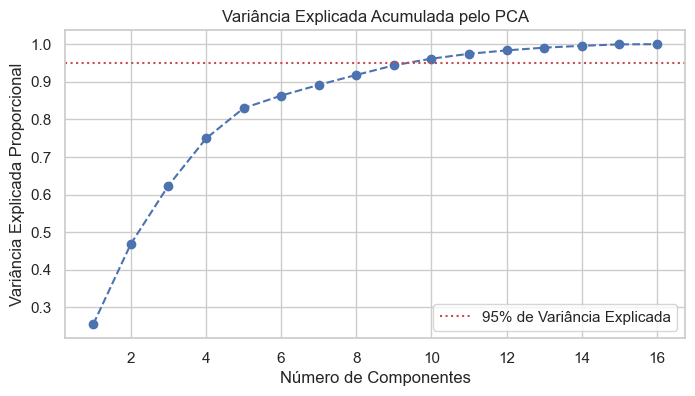

Número de componentes necessários para atingir 95% de variância: 10


In [26]:
# 5. PCA — ANÁLISE DA ESTRUTURA NUMÉRICA
print("=== 5. Analisando as Componentes Principais (PCA) ===")
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_df)

variancia_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada pelo PCA')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Proporcional')
plt.axhline(y=0.95, color='r', linestyle=':', label='95% de Variância Explicada')
plt.legend()
plt.show()

n_componentes_95 = np.argmax(variancia_acumulada >= 0.95) + 1
print(f"Número de componentes necessários para atingir 95% de variância: {n_componentes_95}")

In [27]:
# 6. LR COM PCA — AVALIADO NA VALIDAÇÃO
pca_otimizado = PCA(n_components=n_componentes_95, random_state=RANDOM_STATE)

X_train_pca = pca_otimizado.fit_transform(X_train_df)
X_val_pca = pca_otimizado.transform(X_val_df)

colunas_pca = [f"PC{i}" for i in range(1, n_componentes_95 + 1)]

df_train_pca = pd.DataFrame(X_train_pca, columns=colunas_pca)
df_train_pca['loan_status'] = y_train.values

df_val_pca = pd.DataFrame(X_val_pca, columns=colunas_pca)
df_val_pca['loan_status'] = y_val.values

formula_pca = f"loan_status ~ {' + '.join(colunas_pca)}"

print("Ajustando Regressão Logística Com PCA via Fórmulas...")
modelo_com_pca = smf.logit(formula=formula_pca, data=df_train_pca).fit(disp=0)

y_prob_val_com_pca = modelo_com_pca.predict(df_val_pca)
auc_com_pca = roc_auc_score(df_val_pca['loan_status'], y_prob_val_com_pca)
logloss_com_pca = log_loss(df_val_pca['loan_status'], y_prob_val_com_pca)

print(f"LR Com PCA -> AUC Validação: {auc_com_pca:.4f} | LogLoss: {logloss_com_pca:.4f}")

Ajustando Regressão Logística Com PCA via Fórmulas...
LR Com PCA -> AUC Validação: 0.8675 | LogLoss: 0.3485


In [28]:
# 7. COMPARAR OS TRÊS NA VALIDAÇÃO E ESCOLHER
df_comparativo = pd.DataFrame({
    'Modelo': ['Baseline', 'Regressão Logística Sem PCA', 'Regressão Logística Com PCA'],
    'AUC-ROC (Validação)': [auc_baseline, auc_sem_pca, auc_com_pca],
    'LogLoss (Validação)': [logloss_baseline, logloss_sem_pca, logloss_com_pca]
})

print("=== 7. Tabela Comparativa de Resultados ===")
display(df_comparativo)

if auc_sem_pca >= auc_com_pca:
    print("\n[Decisão] O modelo SEM PCA obteve melhor performance e avançará para o teste final.")
    modelo_final = modelo_sem_pca
    usa_pca = False
else:
    print("\n[Decisão] O modelo COM PCA obteve melhor performance e avançará para o teste final.")
    modelo_final = modelo_com_pca
    usa_pca = True

=== 7. Tabela Comparativa de Resultados ===


,Modelo,AUC-ROC (Validação),LogLoss (Validação)
0,Baseline,0.5000,7.8680
1,Regressão Logística Sem PCA,0.8716,0.3435
2,Regressão Logística Com PCA,0.8675,0.3485



[Decisão] O modelo SEM PCA obteve melhor performance e avançará para o teste final.


In [29]:
# 8. TESTE — USADO UMA ÚNICA VEZ NO MODELO FINAL ESCOLHIDO
print("=== 8. AVALIAÇÃO DEFINITIVA NO DATASET DE TESTE OCULTO ===")

# Passando o dataset bruto intocado pelo pipeline neste exato momento
X_test_np = pipeline_processamento.transform(X_test_raw)
X_test_df = pd.DataFrame(X_test_np, columns=X_train_df.columns)

if not usa_pca:
    df_test_final = X_test_df.copy()
    df_test_final['loan_status'] = y_test.values
    y_prob_final_teste = modelo_final.predict(df_test_final)
else:
    X_test_pca = pca_otimizado.transform(X_test_df)
    df_test_final = pd.DataFrame(X_test_pca, columns=colunas_pca)
    df_test_final['loan_status'] = y_test.values
    y_prob_final_teste = modelo_final.predict(df_test_final)

auc_final_teste = roc_auc_score(df_test_final['loan_status'], y_prob_final_teste)
logloss_final_teste = log_loss(df_test_final['loan_status'], y_prob_final_teste)

print(f"\n[MÉTRICAS OFICIAIS DE TESTE]")
print(f"AUC-ROC Final no Teste : {auc_final_teste:.4f}")
print(f"LogLoss Final no Teste : {logloss_final_teste:.4f}")

print("\nExibindo o Sumário Estatístico de Coeficientes:")
print(modelo_final.summary())

=== 8. AVALIAÇÃO DEFINITIVA NO DATASET DE TESTE OCULTO ===

[MÉTRICAS OFICIAIS DE TESTE]
AUC-ROC Final no Teste : 0.8715
LogLoss Final no Teste : 0.3432

Exibindo o Sumário Estatístico de Coeficientes:
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                22806
Model:                          Logit   Df Residuals:                    22789
Method:                           MLE   Df Model:                           16
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                  0.3353
Time:                        15:14:45   Log-Likelihood:                -7951.8
converged:                       True   LL-Null:                       -11963.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

C:\Users\erica\AppData\Local\Temp\ipykernel_7752\805081576.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
C:\Users\erica\AppData\Local\Temp\ipykernel_7752\805081576.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never w


=== Relatório de Classificação Final ===
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      3821
           1       0.75      0.51      0.61      1066

    accuracy                           0.86      4887
   macro avg       0.81      0.73      0.76      4887
weighted avg       0.85      0.86      0.85      4887

=== Matriz de Confusão ===


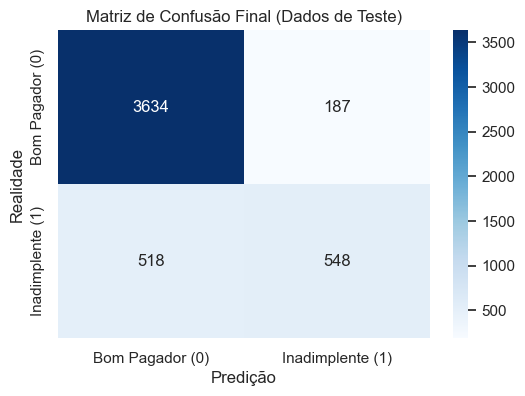

In [30]:
# 9. ERROR ANALYSIS E LIMITAÇÕES
y_pred_final_teste = (y_prob_final_teste >= 0.5).astype(int)

print("\n=== Relatório de Classificação Final ===")
print(classification_report(df_test_final['loan_status'], y_pred_final_teste))

print("=== Matriz de Confusão ===")
cm = confusion_matrix(df_test_final['loan_status'], y_pred_final_teste)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bom Pagador (0)', 'Inadimplente (1)'], 
            yticklabels=['Bom Pagador (0)', 'Inadimplente (1)'])
plt.ylabel('Realidade')
plt.xlabel('Predição')
plt.title('Matriz de Confusão Final (Dados de Teste)')
plt.show()